# Theory-only recursive slab demonstration

This notebook is intentionally independent of the Monte Carlo code and output files.
It demonstrates, using only Python-callable numerical tools, how to construct the
azimuth-integrated recursive slab formalism, compute order-resolved escape
probabilities, evaluate escape-angle distributions, and build simple
order-by-order Comptonized spectra from a 5 eV blackbody seed.

No MCRT binaries are called and no MCRT CSV files are read.


## 1. Imports, style, and numerical settings

The defaults below are chosen for interactive demonstration rather than final
publication precision. Increase `PLOT_DEPTH_GRID`, `DENSE_DEPTH_GRID`, and
`N_MAX` for production-quality convergence checks.


In [90]:
from functools import lru_cache
from math import exp, log, lgamma, sqrt, pi

import numpy as np
import matplotlib.pyplot as plt

# Optional: scipy gives robust special functions if available.  The fallback
# below is pure Python/Numpy and is enough for the E_n orders used here.
try:
    from scipy.special import expn as _scipy_expn
except Exception:
    _scipy_expn = None

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.0,
})

PLOT_DEPTH_GRID = 180
DENSE_DEPTH_GRID = 96
N_MAX = 50
MU_BINS = 120

# The spectrum toy model can use more orders than the probability figures.
# Increase this if the high-energy cutoff is still outside the displayed range.
SPECTRUM_N_MAX = 120
SPECTRUM_DEPTH_GRID = DENSE_DEPTH_GRID
SPECTRUM_E_MIN_EV = 1.0e-1
SPECTRUM_E_MAX_EV = 4.0e6


INJECTION_MODES = ["beam", "lambert", "internal_iso"]
PN_TAUS = [0.1, 1.0, 5.0]
BOUNDARY_TAUS = [0.3, 1.0, 3.0]
ANGLE_TAUS = [0.3, 1.0, 3.0]
ANGLE_ORDERS = [1, 2, 6]
ORDER_COLORS = {1: "C0", 2: "C1", 6: "C2"}


## 2. Generalized exponential integrals and cell-integrated kernels

We use

$$
E_m(x)=\int_1^\infty e^{-xt}t^{-m}\,dt
      = \int_0^1 \mu^{m-2}e^{-x/\mu}\,d\mu.
$$
The slab recursion is discretized with the cell-integrated Appendix-A weights

$$
I_m(0)=2\int_0^{h/2}E_m(s)\,ds,
\qquad
I_m(k)=\int_{(k-1/2)h}^{(k+1/2)h}E_m(s)\,ds,
$$
using $dE_{m+1}/dx=-E_m$, so each block weight is an endpoint difference of
$E_{m+1}$. No midpoint regularization of $E_1(0)$ is used.


In [91]:
EULER_GAMMA = 0.5772156649015328606


def _e1_series(x):
    total = 0.0
    term = 1.0
    for k in range(1, 220):
        term *= -x / k
        add = -term / k
        total += add
        if abs(add) <= 1e-15 * max(1.0, abs(total)):
            break
    return -EULER_GAMMA - log(x) + total


def _e1_continued_fraction(x):
    tiny = 1e-300
    b = x + 1.0
    c = 1.0 / tiny
    d = 1.0 / b
    h = d
    for i in range(1, 220):
        a = -float(i * i)
        b += 2.0
        d = 1.0 / (a * d + b)
        c = b + a / c
        if abs(c) < tiny:
            c = tiny
        delta = c * d
        h *= delta
        if abs(delta - 1.0) < 1e-14:
            break
    return h * exp(-x)


@lru_cache(maxsize=200000)
def _E_scalar(n, x_rounded):
    """Scalar E_n(x) with x rounded by the vector wrapper for caching."""
    x = float(x_rounded)
    if x < 0 and x > -1e-14:
        x = 0.0
    if x < 0:
        raise ValueError("E_n requires x >= 0")
    if x == 0.0:
        if n == 1:
            return np.inf
        return 1.0 / (n - 1)
    e1 = _e1_series(x) if x <= 1.0 else _e1_continued_fraction(x)
    if n == 1:
        return e1
    val = e1
    ex = exp(-x)
    for k in range(1, n):
        val = (ex - x * val) / k
    return val


def E(n, x):
    """Vectorized generalized exponential integral E_n(x).

    Some cell-edge expressions should be exactly zero but can become tiny
    negative values such as -1e-16 after floating-point subtraction.  Clamp only
    that roundoff-scale region before calling scipy.expn, which otherwise
    returns NaN for negative arguments.
    """
    x_arr = np.asarray(x, dtype=float)
    if np.any(x_arr < -1.0e-13):
        raise ValueError("E_n requires x >= 0 apart from roundoff-scale negatives")
    x_arr = np.maximum(x_arr, 0.0)
    if _scipy_expn is not None:
        return _scipy_expn(n, x_arr)
    vec = np.vectorize(lambda y: _E_scalar(int(n), round(float(y), 14)), otypes=[float])
    return vec(x_arr)


def integrated_Em_cell(order, offsets, h):
    """Cell-integrated I_m(k) weights for a vector of offsets k."""
    k = np.asarray(offsets, dtype=float)
    left = np.where(k == 0, 0.0, (k - 0.5) * h)
    right = (k + 0.5) * h
    val = E(order + 1, left) - E(order + 1, right)
    return np.where(k == 0, 2.0 * val, val)


def build_integrated_kernel(tau, depth_grid):
    h = tau / depth_grid
    k = np.arange(depth_grid)
    I1 = integrated_Em_cell(1, k, h)
    I2 = integrated_Em_cell(2, k, h)
    I3 = integrated_Em_cell(3, k, h)
    I4 = integrated_Em_cell(4, k, h)
    I5 = integrated_Em_cell(5, k, h)
    kernel = {
        "I1": I1,
        "I2": I2,
        "I3": I3,
        "I4": I4,
        "I5": I5,
        "Waa": (3.0 / 16.0) * (3.0 * I1 - I3),
        "Wab": (3.0 / 16.0) * (3.0 * I3 - I5),
        "Wba": (3.0 / 16.0) * (-I1 + 3.0 * I3),
        "Wbb": (3.0 / 16.0) * (-I3 + 3.0 * I5),
    }
    for name, arr in kernel.items():
        if not np.all(np.isfinite(arr)):
            raise FloatingPointError(f"non-finite kernel entries in {name}")
    return kernel


## 3. FFT Toeplitz multiplication and source terms

The two-component recursion is

$$
\begin{pmatrix}
a_{n+1} \\
b_{n+1}
\end{pmatrix}_i
=
\sum_j
\begin{pmatrix}
W_{aa}(|i-j|) & W_{ab}(|i-j|) \\
W_{ba}(|i-j|) & W_{bb}(|i-j|)
\end{pmatrix}
\begin{pmatrix}
a_n \\
b_n
\end{pmatrix}_j .
$$
Each symmetric Toeplitz multiplication is evaluated with a circulant embedding
and `numpy.fft`.


In [92]:
def _next_power_of_two(n):
    p = 1
    while p < n:
        p <<= 1
    return p


def toeplitz_fft_prepare(w):
    w = np.asarray(w, dtype=float)
    n = len(w)
    m = _next_power_of_two(2 * n)
    c = np.zeros(m)
    c[:n] = w
    c[m - (n - 1):] = w[1:][::-1]
    return np.fft.fft(c), n, m


def toeplitz_fft_apply(plan, x):
    w_fft, n, m = plan
    xpad = np.zeros(m)
    xpad[:n] = x
    return np.fft.ifft(np.fft.fft(xpad) * w_fft).real[:n]


def prepare_kernel_plans(kernel):
    return {name: toeplitz_fft_prepare(kernel[name]) for name in ["Waa", "Wab", "Wba", "Wbb", "I1", "I3"]}


def first_scatter_beam(t, beam_mu=1.0):
    collision_density = np.exp(-t / beam_mu) / beam_mu
    a = (3.0 / 16.0) * (3.0 - beam_mu**2) * collision_density
    b = (3.0 / 16.0) * (-1.0 + 3.0 * beam_mu**2) * collision_density
    return a, b


def first_scatter_lambert(t):
    E2 = E(2, t)
    E4 = E(4, t)
    a = (3.0 / 8.0) * (3.0 * E2 - E4)
    b = (3.0 / 8.0) * (-E2 + 3.0 * E4)
    return a, b


def first_scatter_internal_iso(t, tau):
    E2_t = E(2, t)
    E2_tau_t = E(2, tau - t)
    E4_t = E(4, t)
    E4_tau_t = E(4, tau - t)

    pref = 3.0 / (32.0 * tau)

    a = pref * (16.0 / 3.0 - 3.0 * E2_t - 3.0 * E2_tau_t + E4_t + E4_tau_t)
    b = pref * (E2_t + E2_tau_t - 3.0 * E4_t - 3.0 * E4_tau_t)
    return a, b


def zero_scatter_escape(tau, injection, beam_mu=1.0):
    if injection == "beam":
        return exp(-tau / beam_mu), 0.0
    if injection == "lambert":
        return 2.0 * float(E(3, tau)), 0.0
    if injection == "internal_iso":
        half = 0.5 * (float(E(3, 0.0)) - float(E(3, tau))) / tau
        return half, half
    raise ValueError(f"unknown injection mode: {injection}")


def first_scatter_state(tau, injection, t, plans, beam_mu=1.0):
    if injection == "beam":
        return first_scatter_beam(t, beam_mu=beam_mu)
    if injection == "lambert":
        return first_scatter_lambert(t)
    if injection == "internal_iso":
        return first_scatter_internal_iso(t, tau)
    raise ValueError(f"unknown injection mode: {injection}")


## 4. Recursive solver and boundary projection

The escape probabilities after the $n$-th scattering are computed from the
stored depth moments.  The zero-scatter term is handled separately for each
source geometry.


In [93]:
def _cell_escape_integrals(tau, depth_grid):
    h = tau / depth_grid
    left = np.arange(depth_grid) * h
    right = (np.arange(depth_grid) + 1.0) * h

    # The upper-boundary last cell has tau-right == 0 analytically.  For some
    # tau values the subtraction produces a tiny negative endpoint, which would
    # make scipy.expn return NaN.  Clamp all escape-kernel distances to the
    # physical domain x >= 0 before evaluating E_m.
    down_left = np.maximum(left, 0.0)
    down_right = np.maximum(right, 0.0)
    up_left = np.maximum(tau - right, 0.0)
    up_right = np.maximum(tau - left, 0.0)

    down_E2 = E(3, down_left) - E(3, down_right)
    down_E4 = E(5, down_left) - E(5, down_right)
    up_E2 = E(3, up_left) - E(3, up_right)
    up_E4 = E(5, up_left) - E(5, up_right)

    for name, arr in {
        "up_E2": up_E2, "up_E4": up_E4, "down_E2": down_E2, "down_E4": down_E4,
    }.items():
        if not np.all(np.isfinite(arr)):
            raise FloatingPointError(f"non-finite escape integral entries in {name}")
    return up_E2, up_E4, down_E2, down_E4


def solve_recursive_distribution(tau, injection, n_max=N_MAX, depth_grid=PLOT_DEPTH_GRID, beam_mu=1.0):
    tau = float(tau)
    h = tau / depth_grid
    t = (np.arange(depth_grid) + 0.5) * h
    kernel = build_integrated_kernel(tau, depth_grid)
    plans = prepare_kernel_plans(kernel)

    p_up = np.zeros(n_max + 1)
    p_down = np.zeros(n_max + 1)
    p_up[0], p_down[0] = zero_scatter_escape(tau, injection, beam_mu=beam_mu)

    a_by_order = [None] * (n_max + 1)
    b_by_order = [None] * (n_max + 1)

    if n_max >= 1:
        a, b = first_scatter_state(tau, injection, t, plans, beam_mu=beam_mu)
        up_E2, up_E4, down_E2, down_E4 = _cell_escape_integrals(tau, depth_grid)
        for n in range(1, n_max + 1):
            p_up[n] = np.sum(a * up_E2 + b * up_E4)
            p_down[n] = np.sum(a * down_E2 + b * down_E4)
            a_by_order[n] = a.copy()
            b_by_order[n] = b.copy()
            if n < n_max:
                next_a = toeplitz_fft_apply(plans["Waa"], a) + toeplitz_fft_apply(plans["Wab"], b)
                next_b = toeplitz_fft_apply(plans["Wba"], a) + toeplitz_fft_apply(plans["Wbb"], b)
                a, b = next_a, next_b

    return {
        "tau": tau,
        "injection": injection,
        "n_max": n_max,
        "depth_grid": depth_grid,
        "cell_width": h,
        "t": t,
        "p_up": p_up,
        "p_down": p_down,
        "p_total": p_up + p_down,
        "a_by_order": a_by_order,
        "b_by_order": b_by_order,
    }


_CASE_CACHE = {}


def get_case(tau, injection, n_max=N_MAX, depth_grid=PLOT_DEPTH_GRID):
    key = (float(tau), injection, int(n_max), int(depth_grid))
    if key not in _CASE_CACHE:
        _CASE_CACHE[key] = solve_recursive_distribution(tau, injection, n_max=n_max, depth_grid=depth_grid)
    return _CASE_CACHE[key]


def dermer_distribution(tau, n_max):
    n = np.arange(n_max + 1)
    return np.exp(-tau) * (1.0 - np.exp(-tau))**n

def esin_distribution(tau, n_max):
    n = np.arange(n_max + 1)
    return np.exp(-tau + n * np.log(tau) - np.vectorize(lgamma)(n + 1.0))


## 5. Order-resolved total escape probability

This is the theory-only counterpart of the paper comparison figure: recursive
$P_n$ against the two common literature approximations, Dermer+91 and Esin+96.


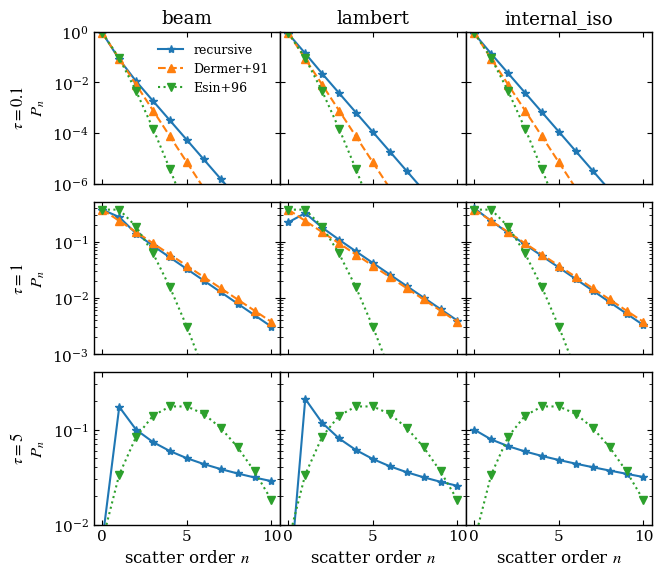

In [94]:
def positive(values):
    arr = np.asarray(values, dtype=float)
    return np.where(arr > 0.0, arr, np.nan)


def plot_pn_total_grid():
    fig, axes = plt.subplots(3, 3, figsize=(7.2, 6.4), sharex=True, sharey="row")
    for row, tau in enumerate(PN_TAUS):
        for col, injection in enumerate(INJECTION_MODES):
            ax = axes[row, col]
            case = get_case(tau, injection)
            n = np.arange(case["n_max"] + 1)
            mask = n <= 10
            ax.plot(n[mask], positive(case["p_total"][mask]), marker="*", linestyle="-", color="C0", label="recursive" if row == 0 and col == 0 else None)
            ax.plot(n[mask], positive(dermer_distribution(tau, case["n_max"])[mask]), marker="^", linestyle="--", color="C1", label="Dermer+91" if row == 0 and col == 0 else None)
            ax.plot(n[mask], positive(esin_distribution(tau, case["n_max"])[mask]), marker="v", linestyle=":", color="C2", label="Esin+96" if row == 0 and col == 0 else None)
            ax.set_yscale("log")
            ax.set_xlim(-0.5, 10.5)
            ax.set_ylim({0.1: (1e-6, 1.0), 1.0: (1e-3, 0.5), 5.0: (1e-2, 0.4)}[tau])
            if row == 0:
                ax.set_title(injection)
            if col == 0:
                ax.set_ylabel(f"$\\tau={tau:g}$\n$P_n$")
            if row == 2:
                ax.set_xlabel(r"scatter order $n$")
    axes[0, 0].legend(loc="best", frameon=False, ncol=1)
    fig.subplots_adjust(wspace=0.0, hspace=0.12)
    plt.show()

plot_pn_total_grid()


## 6. Boundary-resolved escape probabilities

The same recursion directly gives $P_n^+$ and $P_n^-$.  The figure below
keeps only the recursive result and separates the two surfaces with marker
shape/color.


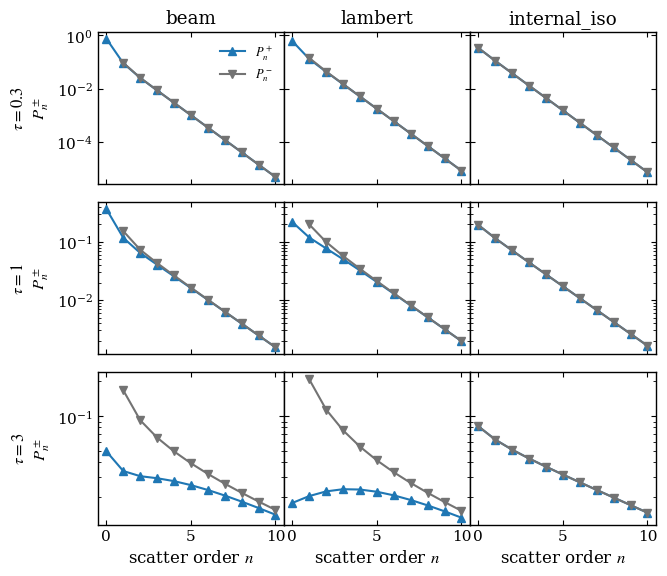

In [95]:
def plot_pn_boundary_grid():
    fig, axes = plt.subplots(3, 3, figsize=(7.2, 6.4), sharex=True, sharey="row")
    for row, tau in enumerate(BOUNDARY_TAUS):
        for col, injection in enumerate(INJECTION_MODES):
            ax = axes[row, col]
            case = get_case(tau, injection)
            n = np.arange(case["n_max"] + 1)
            mask = n <= 10
            ax.plot(n[mask], positive(case["p_up"][mask]), marker="^", linestyle="-", color="C0", label=r"$P_n^+$" if row == 0 and col == 0 else None)
            ax.plot(n[mask], positive(case["p_down"][mask]), marker="v", linestyle="-", color="0.45", label=r"$P_n^-$" if row == 0 and col == 0 else None)
            ax.set_yscale("log")
            ax.set_xlim(-0.5, 10.5)
            # ax.set_ylim(1e-5, 1.0)
            if row == 0:
                ax.set_title(injection)
            if col == 0:
                ax.set_ylabel(f"$\\tau={tau:g}$\n$P_n^\\pm$")
            if row == 2:
                ax.set_xlabel(r"scatter order $n$")
    axes[0, 0].legend(frameon=False, loc="best")
    fig.subplots_adjust(wspace=0.0, hspace=0.12)
    plt.show()

plot_pn_boundary_grid()


## 7. Escape-angle distributions

For $n\ge 1$, the normalized surface angular distribution is built from

$$
\frac{1}{2\pi P_n^\pm}\frac{dP_n^\pm}{d\mu} .
$$
The plotting variable is $\theta=\cos^{-1}\mu$.  The gray curve is a Lambert
reference, $\cos\theta/\pi$, for orientation.


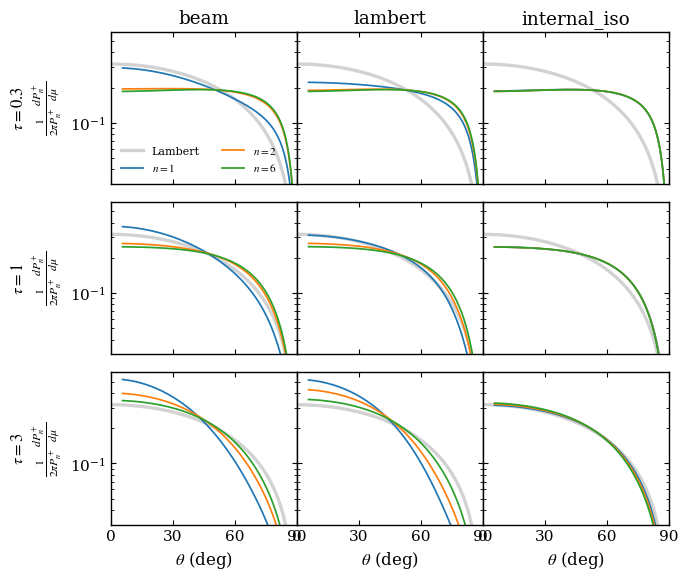

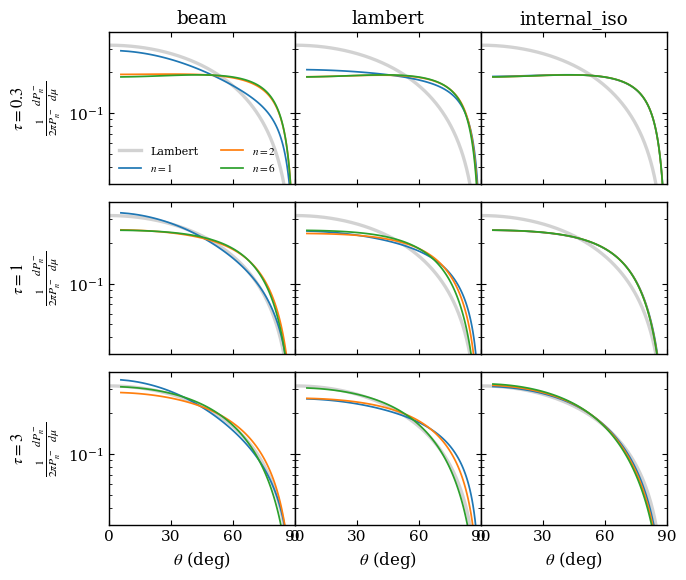

In [96]:
def scattered_density_mu(case, boundary, order, mu):
    mu = np.asarray(mu, dtype=float)
    a = case["a_by_order"][order]
    b = case["b_by_order"][order]
    if a is None or b is None:
        return np.zeros_like(mu)
    t = case["t"]
    h = case["cell_width"]
    left = np.arange(case["depth_grid"]) * h
    right = (np.arange(case["depth_grid"]) + 1.0) * h
    out = np.zeros_like(mu, dtype=float)
    for j, m in enumerate(mu):
        if not (0.0 < m < 1.0):
            out[j] = np.nan
            continue
        if boundary == "up":
            integ = m * (np.exp(-(case["tau"] - right) / m) - np.exp(-(case["tau"] - left) / m))
        else:
            integ = m * (np.exp(-left / m) - np.exp(-right / m))
        out[j] = np.sum((a + b * m * m) * integ)
    return out


def normalized_angle_curve(case, boundary, order, mu):
    p = case["p_up"][order] if boundary == "up" else case["p_down"][order]
    if p <= 0:
        return np.full_like(mu, np.nan, dtype=float)
    return scattered_density_mu(case, boundary, order, mu) / (2.0 * np.pi * p)


def plot_angle_grid(boundary="up"):
    mu = np.linspace(0.01, 0.995, MU_BINS)
    theta = np.degrees(np.arccos(mu))
    fig, axes = plt.subplots(3, 3, figsize=(7.2, 6.4), sharex=True, sharey="row")
    for row, tau in enumerate(ANGLE_TAUS):
        for col, injection in enumerate(INJECTION_MODES):
            ax = axes[row, col]
            case = get_case(tau, injection)
            theta_ref = np.linspace(0.0, 89.9, 300)
            ax.plot(theta_ref, np.cos(np.deg2rad(theta_ref)) / np.pi, color="0.5", alpha=0.35, linewidth=2.4, label="Lambert" if row == 0 and col == 0 else None)
            for order in ANGLE_ORDERS:
                y = normalized_angle_curve(case, boundary, order, mu)
                ax.plot(theta, positive(y), color=ORDER_COLORS[order], linewidth=1.25, label=rf"$n={order}$" if row == 0 and col == 0 else None)
            ax.set_yscale("log")
            ax.set_xlim(0, 90)
            ax.set_ylim(0.03, 0.4 if boundary == "down" else 0.6)
            ax.set_xticks([0, 30, 60, 90])
            if row == 0:
                ax.set_title(injection)
            if col == 0:
                sign = "+" if boundary == "up" else "-"
                ax.set_ylabel(f"$\\tau={tau:g}$\n$\\frac{{1}}{{2\\pi P_n^{sign}}}\\frac{{dP_n^{sign}}}{{d\\mu}}$")
            if row == 2:
                ax.set_xlabel(r"$\theta$ (deg)")
    axes[0, 0].legend(frameon=False, ncol=2, fontsize=8)
    fig.subplots_adjust(wspace=0.0, hspace=0.12)
    plt.show()

plot_angle_grid("up")
plot_angle_grid("down")


### Beam upper-surface asymptotic angular checks

For the beam source, the panel below compares the recursive $n=160$ upper-surface
escape-angle density, normalized as $P_{160}^{+\,-1}dP_{160}^+/d\mu$, with the thin-slab
and thick-slab limiting forms

$$
\frac{(3-\mu^2)\mu\left[1-\exp(-\tau/\mu)\right]}
{5/4-3E_3(\tau)+E_5(\tau)},
\qquad
\mu+\frac{3}{2}\mu^2 .
$$


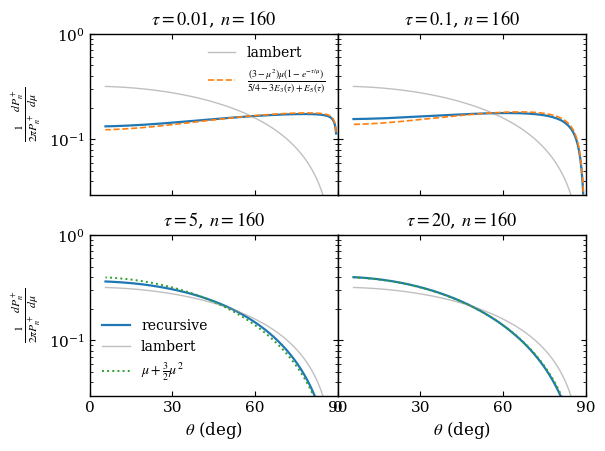

In [97]:
BEAM_ANGLE_CHECK_TAUS = [0.01, 0.1, 5.0, 20.0]
BEAM_ANGLE_CHECK_ORDER = 160
BEAM_ANGLE_CHECK_DEPTH_GRID = 256


def beam_thin_upper_asymptotic(mu, tau):
    """Thin-slab normalized density P_n^{-1} dP_n^+/dmu for beam injection."""
    mu = np.asarray(mu, dtype=float)
    denom = 1.25 - 3.0 * float(E(3, tau)) + float(E(5, tau))
    if denom <= 0.0:
        return np.full_like(mu, np.nan, dtype=float)
    return (3.0 - mu**2) * mu * (1.0 - np.exp(-tau / mu)) / denom


def beam_thick_upper_asymptotic(mu):
    """Optically thick normalized density P_n^{-1} dP_n^+/dmu."""
    mu = np.asarray(mu, dtype=float)
    return mu + 1.5 * mu**2


def recursive_beam_upper_mu_density(tau, order=BEAM_ANGLE_CHECK_ORDER):
    case = get_case(tau, "beam", n_max=order, depth_grid=BEAM_ANGLE_CHECK_DEPTH_GRID)
    mu = np.linspace(0.01, 0.995, 240)
    # This is already (2 pi P_n^+)^{-1} dP_n^+/dmu, matching the main
    # escape-angle distribution panels above.
    y = normalized_angle_curve(case, "up", order, mu)
    return mu, y


def plot_beam_upper_n160_asymptotic_angle_checks():
    fig, axes = plt.subplots(2, 2, figsize=(6.4, 4.7), sharex=True, sharey=True)
    for ax, tau in zip(axes.ravel(), BEAM_ANGLE_CHECK_TAUS):
        mu, y_recursive = recursive_beam_upper_mu_density(tau)
        theta = np.degrees(np.arccos(mu))
        ax.plot(theta, positive(y_recursive), color="C0", linewidth=1.6)
        ax.plot(theta, mu / (np.pi), color="0.55", alpha=0.55, linewidth=1.0)
        if tau <= 0.1:
            y_thin = beam_thin_upper_asymptotic(mu, tau) / (2.0 * np.pi)
            ax.plot(theta, y_thin, color="C1", linestyle="--", linewidth=1.2)
        else:
            y_thick = beam_thick_upper_asymptotic(mu) / (2.0 * np.pi)
            ax.plot(theta, y_thick, color="C2", linestyle=":", linewidth=1.4)
        ax.set_title(rf"$\tau={tau:g}$, $n={BEAM_ANGLE_CHECK_ORDER}$")
        ax.set_xlim(0, 90)
        ax.set_xticks([0, 30, 60, 90])
        ax.set_ylim(0.03, 1)
        ax.set_yscale("log")
        ax.tick_params(direction="in", which="both", top=True, right=True)
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$\frac{1}{2\pi P_n^+}\frac{dP_n^+}{d\mu}$")
    for ax in axes[-1, :]:
        ax.set_xlabel(r"$\theta$ (deg)")
    thin_handles = [
        plt.Line2D([0], [0], color="0.55", alpha=0.55, linewidth=1.0, label="lambert"),
        plt.Line2D(
            [0], [0], color="C1", linestyle="--", linewidth=1.2,
            label=r"$\frac{(3-\mu^2)\mu(1-e^{-\tau/\mu})}{5/4-3E_3(\tau)+E_5(\tau)}$",
        ),
    ]
    thick_handles = [
        plt.Line2D([0], [0], color="C0", linewidth=1.6, label="recursive"),
        plt.Line2D([0], [0], color="0.55", alpha=0.55, linewidth=1.0, label="lambert"),
        plt.Line2D(
            [0], [0], color="C2", linestyle=":", linewidth=1.4,
            label=r"$\mu+\frac{3}{2}\mu^2$",
        ),
    ]
    axes[0, 0].legend(handles=thin_handles, frameon=False, fontsize=10, loc="best")
    axes[1, 0].legend(handles=thick_handles, frameon=False, fontsize=10, loc="best")
    fig.subplots_adjust(wspace=0.0, hspace=0.25)
    plt.show()


plot_beam_upper_n160_asymptotic_angle_checks()


## 8. Mean scattering order and reference trends

The mean scattering order is computed directly from the recursive distribution,

$$
\langle N\rangle = \frac{\sum_n nP_n}{\sum_n P_n} .
$$
The extra trend curves are included only as orientation lines.


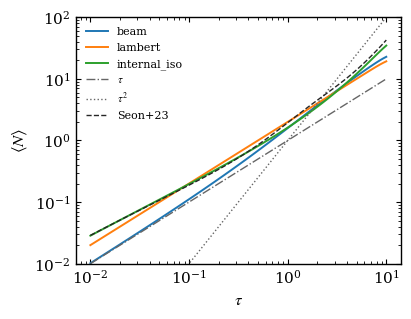

In [98]:
def mean_scatter_count(case):
    n = np.arange(case["n_max"] + 1)
    total = np.sum(case["p_total"])
    return np.sum(n * case["p_total"])


def seon23_like_tau_trend(tau):
    gamma = EULER_GAMMA
    # Seon-like curve after converting their half-slab optical depth convention:
    # tau_Seon = tau / 2.
    ts = np.asarray(tau) / 2.0
    return ts * (1.0 - gamma - np.log(ts) + 5.6 * ts) / (1.0 + ts**2) + 1.5 * ts**2


def plot_mean_scatter_count():
    tau_grid = np.logspace(-2, 1, 100)
    fig, ax = plt.subplots(figsize=(4.2, 3.2))
    for injection in INJECTION_MODES:
        vals = [mean_scatter_count(get_case(tau, injection, n_max=200, depth_grid=DENSE_DEPTH_GRID)) for tau in tau_grid]
        ax.plot(tau_grid, vals, linewidth=1.4, label=injection)
    ax.plot(tau_grid, tau_grid, linestyle="-.", color="0.4", linewidth=1.0, label=r"$\tau$")
    ax.plot(tau_grid, tau_grid**2, linestyle=":", color="0.4", linewidth=1.0, label=r"$\tau^2$")
    ax.plot(tau_grid, seon23_like_tau_trend(tau_grid), linestyle="--", color="0.15", linewidth=1.0, label="Seon+23")
    ax.set_ylim(1e-2, 1e2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\langle N\rangle$")
    ax.legend(frameon=False, fontsize=8, loc="best")
    plt.show()

plot_mean_scatter_count()


### Low-order depth-integrated scattering moments

For each scattering order we define

$$M_n = 4\pi\int_0^\tau \left[a_n(t)+\frac{b_n(t)}{3}\right]\,dt.$$

The following diagnostic shows the low-order behavior for representative optical depths and source geometries.

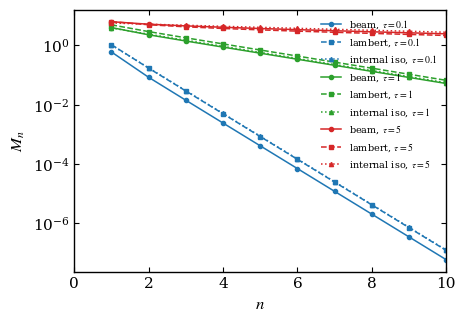

In [99]:
# Low-order M_n distribution diagnostic.
MN_TAUS = [0.1, 1.0, 5.0]
MN_ORDERS = np.arange(1, 11)
MN_COLORS = {0.1: "C0", 1.0: "C2", 5.0: "C3"}
MN_MARKERS = {"beam": "o", "lambert": "s", "internal_iso": "^"}
MN_LINESTYLES = {"beam": "-", "lambert": "--", "internal_iso": ":"}
MN_LABELS = {"beam": "beam", "lambert": "lambert", "internal_iso": "internal iso"}


def order_Mn(case, order):
    a = case["a_by_order"][order]
    b = case["b_by_order"][order]
    if a is None or b is None:
        return 0.0
    return 4.0 * np.pi * case["cell_width"] * np.sum(a + b / 3.0)


def plot_low_order_Mn_distribution():
    fig, ax = plt.subplots(figsize=(4.8, 3.4))
    for tau in MN_TAUS:
        for injection in INJECTION_MODES:
            case = get_case(tau, injection, n_max=int(MN_ORDERS.max()), depth_grid=DENSE_DEPTH_GRID)
            vals = [order_Mn(case, int(n)) for n in MN_ORDERS]
            ax.plot(
                MN_ORDERS,
                positive(vals),
                color=MN_COLORS[tau],
                linestyle=MN_LINESTYLES[injection],
                marker=MN_MARKERS[injection],
                markersize=3.0,
                linewidth=1.1,
                label=rf"{MN_LABELS[injection]}, $\tau={tau:g}$",
            )
    ax.set_yscale("log")
    ax.set_xlim(0, 10)
    ax.set_xticks(np.arange(0, 11, 2))
    ax.set_xlabel(r"$n$")
    ax.set_ylabel(r"$M_n$")
    ax.legend(frameon=False, fontsize=7, loc="upper right")
    ax.tick_params(direction="in", which="both", top=True, right=True)
    plt.show()


plot_low_order_Mn_distribution()


### Large-optical-depth mean-scattering asymptotics test

For $\tau$ up to 100, directly summing many scattering orders becomes
unnecessarily slow and sensitive to truncation.  This diagnostic uses the same
cell-integrated recursion operator $K$, but evaluates the infinite sums

$$
\sum_{n\ge1} P_n = B(I-K)^{-1}u_1,
\qquad
\sum_{n\ge1} nP_n = B(I-K)^{-2}u_1,
$$
where $u_1$ is the first-scattering depth state and $B$ is the escape
projection.  The fitted parameter $z$ is obtained only from the large-$\tau$
part of the computed curves.


1.2430622257754038


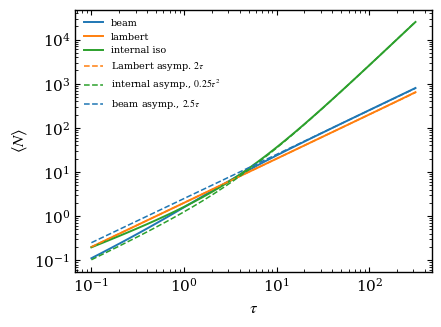

beam         max |probability_sum - 1| = 1.680e-02
lambert      max |probability_sum - 1| = 2.398e-14
internal_iso max |probability_sum - 1| = 1.762e-02


In [100]:
ASYM_TAU_GRID = np.logspace(-1, 2.5, 36)
ASYM_DEPTH_GRID = 1024
ASYM_FIT_TAU_MIN = 50.0


def dense_toeplitz_from_first_column(c):
    idx = np.abs(np.subtract.outer(np.arange(len(c)), np.arange(len(c))))
    return c[idx]


def dense_iteration_matrix_from_kernel(kernel):
    top = np.hstack([
        dense_toeplitz_from_first_column(kernel["Waa"]),
        dense_toeplitz_from_first_column(kernel["Wab"]),
    ])
    bottom = np.hstack([
        dense_toeplitz_from_first_column(kernel["Wba"]),
        dense_toeplitz_from_first_column(kernel["Wbb"]),
    ])
    return np.vstack([top, bottom])


def mean_scatter_count_infinite_sum(tau, injection, depth_grid=ASYM_DEPTH_GRID):
    """Mean order from the infinite recursive series, using the existing kernel."""
    tau = float(tau)
    depth_grid = int(depth_grid)
    h = tau / depth_grid
    t = (np.arange(depth_grid) + 0.5) * h
    kernel = build_integrated_kernel(tau, depth_grid)
    plans = prepare_kernel_plans(kernel)
    a1, b1 = first_scatter_state(tau, injection, t, plans)
    u1 = np.concatenate([a1, b1])

    up_E2, up_E4, down_E2, down_E4 = _cell_escape_integrals(tau, depth_grid)
    escape_vector = np.concatenate([up_E2 + down_E2, up_E4 + down_E4])
    matrix = dense_iteration_matrix_from_kernel(kernel)
    lhs = np.eye(matrix.shape[0]) - matrix

    summed_state = np.linalg.solve(lhs, u1)
    weighted_state = np.linalg.solve(lhs, summed_state)
    p0_up, p0_down = zero_scatter_escape(tau, injection)
    probability_sum = p0_up + p0_down + float(escape_vector @ summed_state)
    weighted_sum = float(escape_vector @ weighted_state)
    mean_n = weighted_sum / probability_sum
    return mean_n, probability_sum


def plot_large_tau_mean_scatter_asymptotics():
    mean_by_mode = {mode: [] for mode in INJECTION_MODES}
    probsum_by_mode = {mode: [] for mode in INJECTION_MODES}
    for tau in ASYM_TAU_GRID:
        for mode in INJECTION_MODES:
            mean_n, prob_sum = mean_scatter_count_infinite_sum(tau, mode)
            mean_by_mode[mode].append(mean_n)
            probsum_by_mode[mode].append(prob_sum)
    mean_by_mode = {mode: np.asarray(vals, dtype=float) for mode, vals in mean_by_mode.items()}

    tau_dense = np.logspace(np.log10(ASYM_TAU_GRID.min()), np.log10(ASYM_TAU_GRID.max()), 500)
    fig, ax = plt.subplots(figsize=(4.6, 3.4))
    colors = {"beam": "C0", "lambert": "C1", "internal_iso": "C2"}
    labels = {"beam": "beam", "lambert": "lambert", "internal_iso": "internal iso"}
    for mode in INJECTION_MODES:
        ax.plot(ASYM_TAU_GRID, mean_by_mode[mode], color=colors[mode], linewidth=1.4, label=labels[mode])

    print((mean_by_mode['beam'] / mean_by_mode['lambert'])[-1])

    ax.plot(tau_dense, 2.0 * tau_dense, color=colors["lambert"], linestyle="--", linewidth=1.1,
            label=r"Lambert asymp. $2\tau$")
    ax.plot(tau_dense, 0.25 * tau_dense**2 + tau_dense,
            color=colors["internal_iso"], linestyle="--", linewidth=1.1,
            label=rf"internal asymp., $0.25\tau^2$")
    ax.plot(tau_dense, 2.5 * tau_dense,
            color=colors["beam"], linestyle="--", linewidth=1.1,
            label=rf"beam asymp., $2.5\tau$")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\langle N\rangle$")
    ax.legend(frameon=False, fontsize=7, loc="best")
    ax.tick_params(direction="in", which="both", top=True, right=True)
    plt.show()

    for mode in INJECTION_MODES:
        max_closure_err = np.max(np.abs(np.asarray(probsum_by_mode[mode]) - 1.0))
        print(f"{mode:12s} max |probability_sum - 1| = {max_closure_err:.3e}")
    return mean_by_mode

large_tau_mean_results = plot_large_tau_mean_scatter_asymptotics()


## 9. Full-integral mean scattered energy

The spectrum toy model below no longer uses the constant soft-photon amplification
factor.  Instead it evaluates the mean scattered photon energy directly from a
stable numerical version of the full Klein-Nishina angular integral.  For an
incident photon energy $\epsilon$ in units of $m_ec^2$, the electron Lorentz
factor is sampled from the Maxwell-Juttner weight
$\gamma^2\beta\exp[-(\gamma-1)/\Theta_e]$, the lab-frame electron direction is
isotropic, and the scattering angle is weighted by the Klein-Nishina differential
cross section in the electron rest frame.  The constants cancel in the ratio, so
the function returns $\langle\epsilon_{\rm out}\rangle$ per scattering.


In [101]:
from functools import lru_cache

MEC2_EV = 5.1099895e5
SEED_KT_EV = 5.0
SEED_PEAK_EV = 2.8214393721220787 * SEED_KT_EV

_QUAD_CACHE = {}


def _legendre_nodes(n, a=-1.0, b=1.0):
    key = ("legendre", int(n), float(a), float(b))
    if key not in _QUAD_CACHE:
        x, w = np.polynomial.legendre.leggauss(int(n))
        xm = 0.5 * (b + a)
        xr = 0.5 * (b - a)
        _QUAD_CACHE[key] = (xm + xr * x, xr * w)
    return _QUAD_CACHE[key]


def _laguerre_nodes(n):
    key = ("laguerre", int(n))
    if key not in _QUAD_CACHE:
        _QUAD_CACHE[key] = np.polynomial.laguerre.laggauss(int(n))
    return _QUAD_CACHE[key]


@lru_cache(maxsize=4096)
def _mean_scattered_energy_full_integral_cached(eps_in, theta_e, n_lag, n_mu, n_scat):
    """Full rate-weighted KN mean energy for one scattering.

    eps_in and the returned value are dimensionless photon energies in m_e c^2.
    The integral is the direct, cancellation-safe version of the Appendix-A
    average: Maxwell-Juttner electrons, relative flux factor (1-beta mu), and
    the Klein-Nishina differential kernel in the electron rest frame.
    """
    eps_in = float(eps_in)
    theta_e = float(theta_e)
    if eps_in <= 0.0 or theta_e <= 0.0:
        return eps_in

    z_nodes, z_weights = _laguerre_nodes(n_lag)
    mu_nodes, mu_weights = _legendre_nodes(n_mu, -1.0, 1.0)
    eta_nodes, eta_weights = _legendre_nodes(n_scat, -1.0, 1.0)

    eta = eta_nodes[None, :]
    eta_weight = eta_weights[None, :]
    sin2_scat = 1.0 - eta * eta

    numerator = 0.0
    denominator = 0.0
    for z, wz in zip(z_nodes, z_weights):
        gamma = 1.0 + theta_e * float(z)
        beta = np.sqrt(max((gamma - 1.0) * (gamma + 1.0), 0.0)) / gamma
        mj_weight = gamma * gamma * beta
        if mj_weight == 0.0:
            continue

        # Lab-frame electron directions are isotropic relative to the photon.
        # The relative flux factor and Lorentz transform set the ERF incident
        # energy and direction cosine relative to the electron velocity.
        rel = np.maximum(1.0 - beta * mu_nodes, 1.0e-300)
        eps_erf = gamma * eps_in * rel
        mu_in_erf = np.clip((mu_nodes - beta) / rel, -1.0, 1.0)

        denom = 1.0 + eps_erf[:, None] * (1.0 - eta)
        energy_ratio_erf = 1.0 / denom
        kn_kernel = energy_ratio_erf**2 * (
            energy_ratio_erf + 1.0 / energy_ratio_erf - sin2_scat
        )

        eps_out_erf = eps_erf[:, None] * energy_ratio_erf
        # Azimuth has been integrated analytically.  The cos(phi) term averages
        # to zero, leaving mu_out,ERF = mu_in,ERF * cos(scattering angle).
        eps_out_lab = gamma * eps_out_erf * (1.0 + beta * mu_in_erf[:, None] * eta)

        weight = (
            float(wz)
            * mj_weight
            * rel[:, None]
            * mu_weights[:, None]
            * eta_weight
            * kn_kernel
        )
        numerator += float(np.sum(weight * eps_out_lab))
        denominator += float(np.sum(weight))

    if denominator <= 0.0 or not np.isfinite(numerator) or not np.isfinite(denominator):
        raise FloatingPointError("invalid full-integral mean scattered energy")
    return numerator / denominator


def mean_scattered_energy_full_integral_mec2(eps_in, theta_e, n_lag=48, n_mu=48, n_scat=64):
    eps_key = round(float(eps_in), 14)
    theta_key = round(float(theta_e), 8)
    return _mean_scattered_energy_full_integral_cached(
        eps_key, theta_key, int(n_lag), int(n_mu), int(n_scat)
    )


def mean_scattered_energy_full_integral_eV(E_eV, theta_e, **kwargs):
    return MEC2_EV * mean_scattered_energy_full_integral_mec2(float(E_eV) / MEC2_EV, theta_e, **kwargs)


def energy_amplification(theta_e, reference_energy_eV=SEED_PEAK_EV):
    """One-scattering full-integral gain at the chosen reference photon energy.

    Accepts either a scalar or a NumPy array of electron temperatures.  The
    expensive scalar integral is cached, so vector calls remain practical for
    the diagnostic alpha plot.
    """
    theta_arr = np.asarray(theta_e, dtype=float)
    def _scalar_gain(theta_scalar):
        return mean_scattered_energy_full_integral_eV(reference_energy_eV, float(theta_scalar)) / reference_energy_eV
    if theta_arr.ndim == 0:
        return _scalar_gain(float(theta_arr))
    vals = [_scalar_gain(v) for v in theta_arr.ravel()]
    return np.asarray(vals, dtype=float).reshape(theta_arr.shape)


def mean_energy_peak_sequence_full_integral(theta_e, n_max, seed_energy_eV=SEED_PEAK_EV):
    """Reference energy after n scatterings using the full-integral mean map."""
    energies = np.empty(int(n_max) + 1, dtype=float)
    energies[0] = float(seed_energy_eV)
    for n in range(1, len(energies)):
        energies[n] = mean_scattered_energy_full_integral_eV(energies[n - 1], theta_e)
    return energies


for theta_demo in [0.1, 0.5]:
    print(
        f"Theta={theta_demo:g}: full-integral first-scattering gain "
        f"A(E_seed_peak)={energy_amplification(theta_demo):.6f}"
    )


Theta=0.1: full-integral first-scattering gain A(E_seed_peak)=1.506545
Theta=0.5: full-integral first-scattering gain A(E_seed_peak)=6.099652


## 10. Asymptotic ratio diagnostics

At sufficiently high order, $P_n/P_{n-1}$ approaches the dominant eigenvalue
of the recursion.  This section only visualizes the finite-order approach to
that limit.  The spectral-index proxy is evaluated below from the matrix
spectral radius after the spectral-radius calculation.


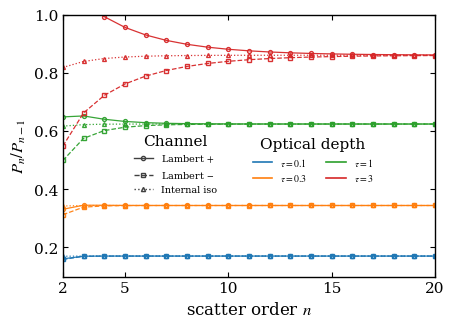

In [102]:
RATIO_N_VALUES = np.arange(2, 21)
RATIO_TAUS = [0.1, 0.3, 1.0, 3.0]
RATIO_CHANNELS = [
    ("lambert", "up", r"Lambert $+$", "-", "o"),
    ("lambert", "down", r"Lambert $-$", "--", "s"),
    ("internal_iso", "total", r"Internal iso", ":", "^"),
]
TAU_COLORS = {0.1: "C0", 0.3: "C1", 1.0: "C2", 3.0: "C3"}


def ratio_table(case, n_start=2, n_end=20, which="total"):
    p = {"total": case["p_total"], "up": case["p_up"], "down": case["p_down"]}[which]
    n = np.arange(n_start, n_end + 1)
    ratio = p[n] / p[n - 1]
    return n, ratio


def ratio_curve_for_channel(tau, injection, which, n_values=RATIO_N_VALUES):
    case = get_case(tau, injection, n_max=max(n_values), depth_grid=DENSE_DEPTH_GRID)
    p = {"total": case["p_total"], "up": case["p_up"], "down": case["p_down"]}[which]
    vals = []
    for n in n_values:
        vals.append(p[n] / p[n - 1] if p[n - 1] > 0 else np.nan)
    return np.asarray(vals, dtype=float)


def plot_ratio_convergence_single_panel():
    fig, ax = plt.subplots(figsize=(4.8, 3.4))
    for tau in RATIO_TAUS:
        for injection, which, label, linestyle, marker in RATIO_CHANNELS:
            y = ratio_curve_for_channel(tau, injection, which)
            ax.plot(
                RATIO_N_VALUES,
                y,
                color=TAU_COLORS[tau],
                linestyle=linestyle,
                marker=marker,
                markersize=2.8,
                markerfacecolor="none",
                linewidth=0.9,
                alpha=0.95,
            )
    tau_handles = [plt.Line2D([0], [0], color=TAU_COLORS[tau], lw=1.2, label=rf"$\tau={tau:g}$") for tau in RATIO_TAUS]
    style_handles = [
        plt.Line2D([0], [0], color="0.25", lw=1.0, linestyle=ls, marker=mk, markersize=3.0,
                   markerfacecolor="none", label=label)
        for _, _, label, ls, mk in RATIO_CHANNELS
    ]
    leg1 = ax.legend(handles=tau_handles, loc=(0.50, 0.34), ncol=2, frameon=False, fontsize=7, title=r"Optical depth")
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc=(0.18, 0.30), frameon=False, fontsize=7, title="Channel")
    ax.set_xlim(2, 20)
    ax.set_ylim(0.1, 1.0)
    ax.set_xticks([2, 5, 10, 15, 20])
    ax.set_xlabel(r"scatter order $n$")
    ax.set_ylabel(r"$P_n/P_{n-1}$")
    ax.tick_params(direction="in", which="both", top=True, right=True)
    plt.show()


plot_ratio_convergence_single_panel()


## 11. Spectral radius of the recursive matrix

The high-order limit of the scattering probability ratio is controlled by the
Perron root of the Appendix-A two-component recursion operator.  The cell below
constructs the explicit $2N\times2N$ block Toeplitz matrix, estimates its
spectral radius over a logarithmic optical-depth grid, and compares it with
$P_{20}/P_{19}$, the thin-slab trend, the optically thick diffusion trend, and
the Titarchuk (1994) interpolation formula.


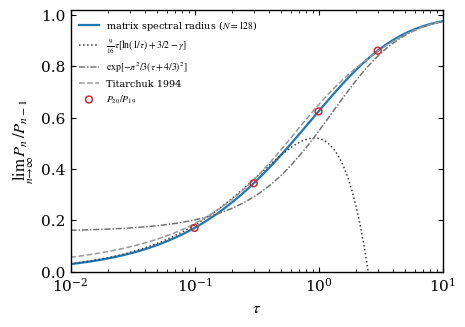

In [103]:
SPECTRAL_TAU_GRID = np.logspace(-2, 1, 100)
SPECTRAL_DEPTH_GRID = 128
SPECTRAL_POWER_MAXITER = 500
SPECTRAL_POWER_TOL = 1.0e-11


def toeplitz_from_first_column(c):
    idx = np.abs(np.subtract.outer(np.arange(len(c)), np.arange(len(c))))
    return c[idx]


def build_iteration_matrix(tau, depth_grid=SPECTRAL_DEPTH_GRID):
    kernel = build_integrated_kernel(float(tau), int(depth_grid))
    top = np.hstack([
        toeplitz_from_first_column(kernel["Waa"]),
        toeplitz_from_first_column(kernel["Wab"]),
    ])
    bottom = np.hstack([
        toeplitz_from_first_column(kernel["Wba"]),
        toeplitz_from_first_column(kernel["Wbb"]),
    ])
    return np.vstack([top, bottom])


def spectral_radius_power(tau, depth_grid=SPECTRAL_DEPTH_GRID):
    matrix = build_iteration_matrix(tau, depth_grid=depth_grid)
    if not np.all(np.isfinite(matrix)):
        raise FloatingPointError(f"non-finite matrix entries for tau={tau}")
    x = np.ones(matrix.shape[0], dtype=float)
    x /= np.linalg.norm(x)
    lam_old = 0.0
    for _ in range(SPECTRAL_POWER_MAXITER):
        y = matrix @ x
        norm_y = np.linalg.norm(y)
        if norm_y == 0.0 or not np.isfinite(norm_y):
            return np.nan
        x = y / norm_y
        lam = float(x @ (matrix @ x) / (x @ x))
        if abs(lam - lam_old) <= SPECTRAL_POWER_TOL * max(1.0, abs(lam)):
            break
        lam_old = lam
    return abs(lam)


def p20_over_p19_points(tau_values=RATIO_TAUS):
    rows = []
    for tau in tau_values:
        case = get_case(tau, "internal_iso", n_max=20, depth_grid=DENSE_DEPTH_GRID)
        p19 = case["p_total"][19]
        p20 = case["p_total"][20]
        rows.append((tau, p20 / p19 if p19 > 0 else np.nan))
    return np.asarray(rows, dtype=float)


rho_values = np.array([spectral_radius_power(tau) for tau in SPECTRAL_TAU_GRID])
ratio_points = p20_over_p19_points()


def thin_tau_radius_approx(tau):
    tau = np.asarray(tau, dtype=float)
    return (9.0 / 16.0) * tau * (np.log(1.0 / tau) + 1.5 - EULER_GAMMA)


def thick_tau_radius_approx(tau):
    tau = np.asarray(tau, dtype=float)
    return np.exp(-np.pi**2 / (3.0 * (tau + 4.0 / 3.0)**2))


def titarchuk_1994_radius(tau):
    tau = np.asarray(tau, dtype=float)
    return np.exp(
        -np.pi**2 / (3.0 * (tau + 4.0 / 3.0)**2) * (1.0 - np.exp(-0.675 * tau))
        - 0.45 * np.exp(-1.85 * tau) * np.log(20.0 / (3.0 * tau))
    )


def plot_spectral_radius():
    fig, ax = plt.subplots(figsize=(4.8, 3.4))
    ax.plot(SPECTRAL_TAU_GRID, rho_values, color="C0", linewidth=1.6, label=rf"matrix spectral radius ($N={SPECTRAL_DEPTH_GRID}$)")
    ax.plot(SPECTRAL_TAU_GRID, thin_tau_radius_approx(SPECTRAL_TAU_GRID), color="0.25", linestyle=":", linewidth=1.1,
            label=r"$\frac{9}{16}\tau[\ln(1/\tau)+3/2-\gamma]$")
    ax.plot(SPECTRAL_TAU_GRID, thick_tau_radius_approx(SPECTRAL_TAU_GRID), color="0.45",
            linestyle=(0, (4.0, 1.2, 1.0, 1.2)), linewidth=1.1,
            label=r"$\exp[-\pi^2/3(\tau+4/3)^2]$")
    ax.plot(SPECTRAL_TAU_GRID, titarchuk_1994_radius(SPECTRAL_TAU_GRID), color="0.60", linestyle="--", linewidth=1.1,
            label="Titarchuk 1994")
    ax.scatter(ratio_points[:, 0], ratio_points[:, 1], s=24, marker="o", facecolor="none", edgecolor="C3",
               linewidth=1.1, zorder=5, label=r"$P_{20}/P_{19}$")
    ax.set_xscale("log")
    ax.set_xlim(1e-2, 1e1)
    ax.set_ylim(0.0, 1.02)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\lim_{n\to\infty} P_n/P_{n-1}$")
    ax.tick_params(direction="in", which="both", top=True, right=True)
    ax.legend(loc="upper left", frameon=False, fontsize=7)
    plt.show()


plot_spectral_radius()


## Spectral-index proxy from the matrix spectral radius

The spectral-index estimate uses the asymptotic ratio from the recursive operator,

$$
\alpha_X(\tau,\Theta_e) =
-\frac{\ln \rho(\tau)}{
\ln\left[1+4\Theta_e\,\frac{\mathrm{ExpBesselK}(1,1/\Theta_e)}
{\mathrm{ExpBesselK}(2,1/\Theta_e)}+16\Theta_e^2\right]}
$$
where $\rho(\tau)$ is the matrix spectral radius.  The same panel also shows
the HT95 slab/disk fixed-point estimate at the same optical depths and electron
temperatures.


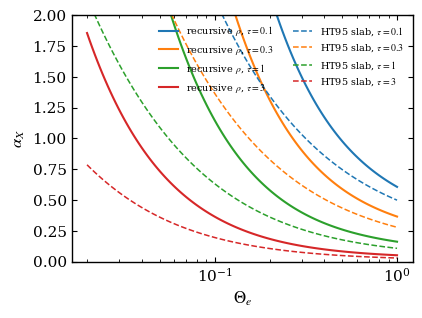

{0.1: 0.1705218462569689,
 0.3: 0.34436438157836025,
 1.0: 0.6244509526682236,
 3.0: 0.8609345083480697}

In [104]:
try:
    from scipy.special import kve as _scaled_besselk_for_alpha
except Exception:
    _scaled_besselk_for_alpha = None

try:
    from scipy.special import gamma as _gamma_for_ht95
except Exception:
    _gamma_for_ht95 = None


def exp_bessel_k_ratio_1_2(theta_e):
    """ExpBesselK(1,1/theta) / ExpBesselK(2,1/theta)."""
    theta = np.asarray(theta_e, dtype=float)
    x = 1.0 / theta
    if _scaled_besselk_for_alpha is not None:
        return _scaled_besselk_for_alpha(1, x) / _scaled_besselk_for_alpha(2, x)
    import mpmath as mp
    vals = []
    for value in np.ravel(x):
        vals.append(float(mp.exp(value) * mp.besselk(1, value) / (mp.exp(value) * mp.besselk(2, value))))
    return np.asarray(vals, dtype=float).reshape(theta.shape)


def soft_photon_thermal_gain(theta_e):
    theta = np.asarray(theta_e, dtype=float)
    return 1.0 + 4.0 * theta * exp_bessel_k_ratio_1_2(theta) + 16.0 * theta**2


def spectral_radius_for_alpha(tau):
    """Use the matrix spectral radius as the asymptotic P_n/P_{n-1}."""
    return spectral_radius_power(float(tau))


def alpha_from_spectral_radius(rho, theta_e):
    rho = np.clip(float(rho), 1.0e-300, 1.0 - 1.0e-15)
    gain = soft_photon_thermal_gain(theta_e)
    return -np.log(rho) / np.log(gain)


def ht95_beta_disk(tau0):
    tau0 = np.maximum(np.asarray(tau0, dtype=float), 1.0e-4)
    tau_eff = tau0 + 2.0 / 3.0
    term1 = (np.pi**2 / (12.0 * tau_eff**2)) * (1.0 - np.exp(-1.35 * tau0))
    term2 = 0.45 * np.exp(-3.7 * tau0) * np.log(10.0 / (3.0 * tau0))
    return term1 + term2


def ht95_alpha_t94_seed(beta, theta_e):
    theta = np.asarray(theta_e, dtype=float)
    f_theta = 2.5 * theta + 1.875 * theta**2 * (1.0 - theta)
    gamma_val = beta / (theta * (1.0 + f_theta))
    return np.sqrt(2.25 + gamma_val) - 1.5


def ht95_d0(alpha):
    alpha = np.asarray(alpha, dtype=float)
    if _gamma_for_ht95 is not None:
        return 3.0 * (((alpha + 3.0) * alpha) + 4.0) * _gamma_for_ht95(2.0 * alpha + 2.0) / ((alpha + 3.0) * (alpha + 2.0)**2)
    import mpmath as mp
    vals = []
    for value in alpha.ravel():
        vals.append(float(3.0 * (((value + 3.0) * value) + 4.0) * mp.gamma(2.0 * value + 2.0) / ((value + 3.0) * (value + 2.0)**2)))
    return np.asarray(vals, dtype=float).reshape(alpha.shape)


def alpha_ht95_disk(theta_e, tau, iterations=50):
    theta = np.asarray(theta_e, dtype=float)
    beta = ht95_beta_disk(tau)
    alpha = ht95_alpha_t94_seed(beta, theta)
    for _ in range(iterations):
        d0 = ht95_d0(alpha)
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            d0_power = np.exp(np.log(np.maximum(d0, 1.0e-300)) / np.maximum(alpha, 1.0e-12))
        log_arg = 1.0 + (alpha + 3.0) * theta / (1.0 + theta) + 4.0 * d0_power * theta**2
        alpha_next = beta / np.log(np.maximum(log_arg, 1.0 + 1.0e-300))
        alpha = np.where(np.isfinite(alpha_next), alpha_next, alpha)
    return alpha


def plot_alpha_theta_from_spectral_radius():
    theta_grid = np.logspace(np.log10(0.02), 0.0, 120)
    fig, ax = plt.subplots(figsize=(4.4, 3.2))
    rho_by_tau = {tau: spectral_radius_for_alpha(tau) for tau in RATIO_TAUS}
    color_by_tau = {}
    for tau in RATIO_TAUS:
        alpha = alpha_from_spectral_radius(rho_by_tau[tau], theta_grid)
        line, = ax.plot(theta_grid, alpha, label=rf"recursive $\rho$, $\tau={tau:g}$")
        color_by_tau[tau] = line.get_color()
    for tau in RATIO_TAUS:
        ax.plot(
            theta_grid,
            alpha_ht95_disk(theta_grid, tau),
            color=color_by_tau[tau],
            linestyle="--",
            linewidth=1.1,
            label=rf"HT95 slab, $\tau={tau:g}$",
        )
    ax.set_xscale("log")
    ax.set_ylim(0, 2)
    ax.set_xlabel(r"$\Theta_e$")
    ax.set_ylabel(r"$\alpha_X$")
    ax.legend(frameon=False, fontsize=7, ncol=2)
    plt.show()
    return rho_by_tau

alpha_spectral_radius_by_tau = plot_alpha_theta_from_spectral_radius()
alpha_spectral_radius_by_tau


### HT95 versus the eigenvalue diffusion-index formula

This diagnostic compares the HT95 slab fixed-point result with the common
eigenvalue form

$$
\alpha_X = \sqrt{\frac{9}{4}-\frac{\ln\lambda(\tau)}{\Theta_e}}-\frac{3}{2},
$$
where here $\lambda(\tau)$ is taken to be the recursive matrix spectral radius
$\rho(\tau)$.


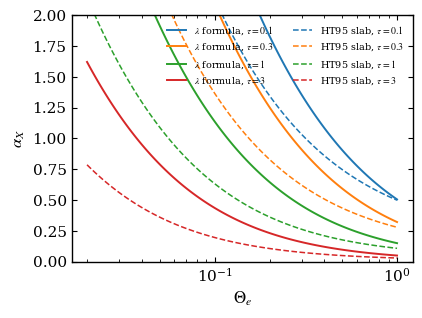

In [105]:
def alpha_from_lambda_diffusion(theta_e, lambda_tau):
    theta = np.asarray(theta_e, dtype=float)
    lam = np.clip(float(lambda_tau), 1.0e-300, 1.0 - 1.0e-15)
    return np.sqrt(2.25 - np.log(lam) / theta) - 1.5


def plot_ht95_vs_lambda_alpha():
    theta_grid = np.logspace(np.log10(0.02), 0.0, 120)
    fig, ax = plt.subplots(figsize=(4.4, 3.2))
    try:
        lambda_by_tau = alpha_spectral_radius_by_tau
    except NameError:
        lambda_by_tau = {tau: spectral_radius_for_alpha(tau) for tau in RATIO_TAUS}

    color_by_tau = {}
    for tau in RATIO_TAUS:
        alpha_lambda = alpha_from_lambda_diffusion(theta_grid, lambda_by_tau[tau])
        line, = ax.plot(theta_grid, alpha_lambda, linewidth=1.4, label=rf"$\lambda$ formula, $\tau={tau:g}$")
        color_by_tau[tau] = line.get_color()
    for tau in RATIO_TAUS:
        ax.plot(
            theta_grid,
            alpha_ht95_disk(theta_grid, tau),
            color=color_by_tau[tau],
            linestyle="--",
            linewidth=1.1,
            label=rf"HT95 slab, $\tau={tau:g}$",
        )

    ax.set_xscale("log")
    ax.set_ylim(0, 2)
    ax.set_xlabel(r"$\Theta_e$")
    ax.set_ylabel(r"$\alpha_X$")
    ax.legend(frameon=False, fontsize=7, ncol=2)
    ax.tick_params(direction="in", which="both", top=True, right=True)
    plt.show()

plot_ht95_vs_lambda_alpha()


### HT95 versus modified eigenvalue diffusion-index formula

This diagnostic uses the updated denominator correction

$$
\alpha_X = \sqrt{\frac{9}{4}
-\frac{\ln\lambda(\tau)}{\Theta_e}
\frac{\mathrm{ExpBesselK}(2,1/\Theta_e)}
{\mathrm{ExpBesselK}(3,1/\Theta_e)}}
-\frac{3}{2},
$$
again taking $\lambda(\tau)=\rho(\tau)$, and compares it with the HT95 slab
fixed-point result.


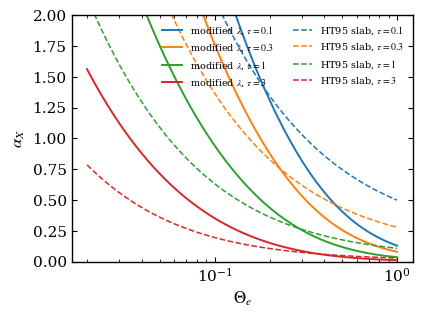

In [106]:
def exp_bessel_k_ratio_2_3(theta_e):
    """ExpBesselK(2,1/theta) / ExpBesselK(3,1/theta)."""
    theta = np.asarray(theta_e, dtype=float)
    x = 1.0 / theta
    if _scaled_besselk_for_alpha is not None:
        return _scaled_besselk_for_alpha(2, x) / _scaled_besselk_for_alpha(3, x)
    import mpmath as mp
    vals = []
    for value in np.ravel(x):
        vals.append(float(mp.exp(value) * mp.besselk(2, value) / (mp.exp(value) * mp.besselk(3, value))))
    return np.asarray(vals, dtype=float).reshape(theta.shape)


def alpha_from_lambda_modified_diffusion(theta_e, lambda_tau):
    theta = np.asarray(theta_e, dtype=float)
    lam = np.clip(float(lambda_tau), 1.0e-300, 1.0 - 1.0e-15)
    correction = exp_bessel_k_ratio_2_3(theta)
    return np.sqrt(2.25 - (np.log(lam) / theta) * correction) - 1.5


def plot_ht95_vs_modified_lambda_alpha():
    theta_grid = np.logspace(np.log10(0.02), 0.0, 120)
    fig, ax = plt.subplots(figsize=(4.4, 3.2))
    try:
        lambda_by_tau = alpha_spectral_radius_by_tau
    except NameError:
        lambda_by_tau = {tau: spectral_radius_for_alpha(tau) for tau in RATIO_TAUS}

    color_by_tau = {}
    for tau in RATIO_TAUS:
        alpha_lambda = alpha_from_lambda_modified_diffusion(theta_grid, lambda_by_tau[tau])
        line, = ax.plot(theta_grid, alpha_lambda, linewidth=1.4, label=rf"modified $\lambda$, $\tau={tau:g}$")
        color_by_tau[tau] = line.get_color()
    for tau in RATIO_TAUS:
        ax.plot(
            theta_grid,
            alpha_ht95_disk(theta_grid, tau),
            color=color_by_tau[tau],
            linestyle="--",
            linewidth=1.1,
            label=rf"HT95 slab, $\tau={tau:g}$",
        )

    ax.set_xscale("log")
    ax.set_ylim(0, 2)
    ax.set_xlabel(r"$\Theta_e$")
    ax.set_ylabel(r"$\alpha_X$")
    ax.legend(frameon=False, fontsize=7, ncol=2)
    ax.tick_params(direction="in", which="both", top=True, right=True)
    plt.show()

plot_ht95_vs_modified_lambda_alpha()


## 12. Approximate spectra from order probabilities

This last section uses the recursive $P_n^\pm$ and a blackbody seed shape to
build a simple peak-tracked spectrum.  The reference energy for order $n+1$ is
computed from the order-$n$ reference energy with the full-integral mean
scattered-energy map above, so the peaks are not forced to follow a constant
amplification factor.  The construction is still a compact spectral surrogate,
not a replacement for full Compton-scattering MCRT.  The number of scattering orders used here is controlled by `SPECTRUM_N_MAX`, independently of the lower-order probability figures.


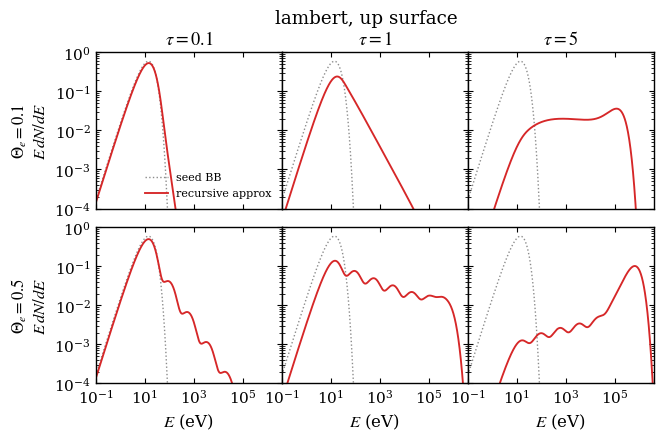

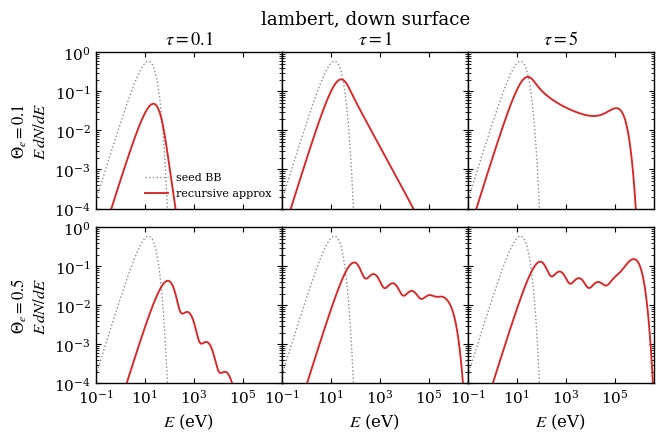

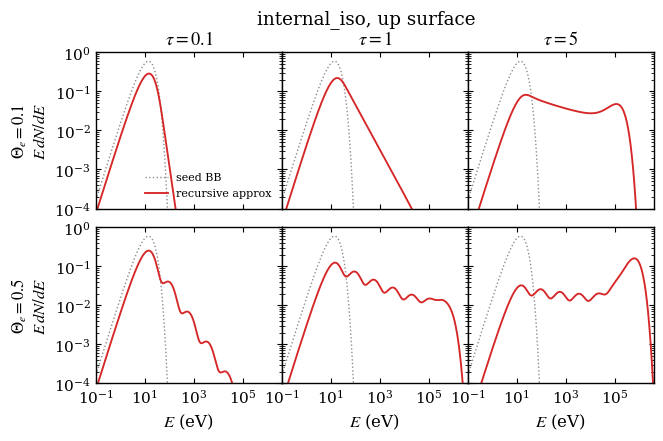

In [107]:
ENERGY_EV = np.logspace(-1, np.log10(4.0e6), 900)
SPECTRUM_THETAS = [0.1, 0.5]
SPECTRUM_TAUS = [0.1, 1.0, 5.0]


def seed_photon_pdf(E_eV, kT_eV=SEED_KT_EV):
    E_eV = np.asarray(E_eV, dtype=float)
    x = np.clip(E_eV / kT_eV, 1e-12, 700.0)
    y = E_eV**2 / np.expm1(x)
    norm_grid = np.logspace(-3, 8, 6000)
    nx = np.clip(norm_grid / kT_eV, 1e-12, 700.0)
    norm_y = norm_grid**2 / np.expm1(nx)
    return y / np.trapezoid(norm_y, norm_grid)


def shifted_seed_pdf(E_eV, reference_energy_eV):
    gain = max(float(reference_energy_eV) / SEED_PEAK_EV, 1e-300)
    return seed_photon_pdf(np.asarray(E_eV) / gain) / gain


def approximate_spectrum(E_eV, injection, boundary, tau, theta_e):
    case = get_case(tau, injection, n_max=SPECTRUM_N_MAX, depth_grid=SPECTRUM_DEPTH_GRID)
    probs = case["p_up"] if boundary == "up" else case["p_down"]
    reference_energies = mean_energy_peak_sequence_full_integral(theta_e, SPECTRUM_N_MAX)
    y = np.zeros_like(E_eV)
    for n, p_n in enumerate(probs):
        if p_n <= 0:
            continue
        # No additional thermal-KN scattering-rate suppression is applied in
        # this theory-only notebook; only the full-integral energy shift is used.
        y += p_n * shifted_seed_pdf(E_eV, reference_energies[n])
    return y


def plot_approx_spectrum_grid(injection="lambert", boundary="up"):
    fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.3), sharex=True, sharey=True)
    for row, theta_e in enumerate(SPECTRUM_THETAS):
        for col, tau in enumerate(SPECTRUM_TAUS):
            ax = axes[row, col]
            seed = seed_photon_pdf(ENERGY_EV)
            spec = approximate_spectrum(ENERGY_EV, injection, boundary, tau, theta_e)
            ax.plot(ENERGY_EV, ENERGY_EV * seed, color="0.55", linestyle=":", linewidth=1.0, label="seed BB" if row == 0 and col == 0 else None)
            ax.plot(ENERGY_EV, positive(ENERGY_EV * spec), color="C3", linewidth=1.35, label="recursive approx" if row == 0 and col == 0 else None)
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(SPECTRUM_E_MIN_EV, SPECTRUM_E_MAX_EV)
            ax.set_ylim(1e-4, 1.0)
            if row == 0:
                ax.set_title(rf"$\tau={tau:g}$")
            if col == 0:
                ax.set_ylabel(f"$\\Theta_e={theta_e:g}$\n$E\\,dN/dE$")
            if row == 1:
                ax.set_xlabel(r"$E$ (eV)")
    axes[0, 0].legend(frameon=False, fontsize=8)
    fig.suptitle(f"{injection}, {boundary} surface")
    fig.subplots_adjust(wspace=0.0, hspace=0.12, top=0.88)
    plt.show()

plot_approx_spectrum_grid("lambert", "up")
plot_approx_spectrum_grid("lambert", "down")
plot_approx_spectrum_grid("internal_iso", "up")


## Transport-equation check for $Q(t,\Omega)$

This diagnostic solves the azimuth-averaged discrete-ordinates form of

$$
\mu\frac{\partial Q}{\partial t}
= Q(t,\Omega)-\left[1+\int d\Omega'\,p(\Omega'|\Omega)Q(t,\Omega')\right]
$$

with the slab boundary conditions

$$
Q(0,\Omega)=0\quad(\mu<0),\qquad Q(\tau,\Omega)=0\quad(\mu>0).
$$

The Thomson phase function is integrated over azimuth for an axisymmetric
solution before solving the coupled two-point boundary-value problem.

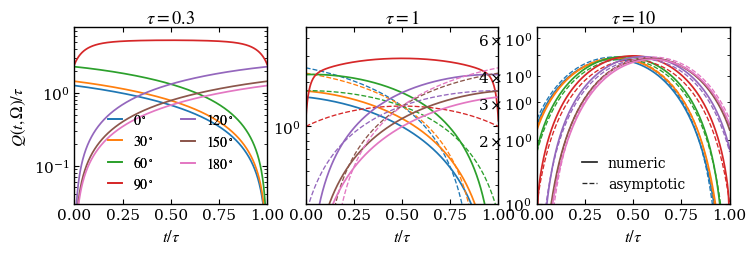

In [109]:
# Discrete-ordinates solution of the Q(t, Omega) boundary-value problem.
# The three columns compare numerical solutions with the large-depth reference.
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from matplotlib.lines import Line2D


def _q_three_column_size(row_height_scale=1.0):
    """Local double-column three-panel figure size for this theory-only demo."""
    return 7.2, 2.4 * row_height_scale


Q_TAU_VALUES = [0.3, 1.0, 10.0]
Q_DEPTH_POINTS = 1000
Q_MU_POINTS = 80
Q_THETA_DEGREES = [0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0]
Q_YLIM_LOWER = {0.3: 3e-2, 1.0: 3e-1, 10.0: 1}


def _thomson_azimuth_integrated_kernel(mu_nodes, mu_weights):
    """Return quadrature matrix for int dOmega' p(Omega'|Omega) Q(mu').

    For an axisymmetric Q, the azimuth-integrated Thomson kernel is

        K(mu, mu') = 3/16 [3 - mu^2 - mu'^2 + 3 mu^2 mu'^2],

    so the returned matrix already includes the Gauss-Legendre weights dmu'.
    """
    mu = np.asarray(mu_nodes, dtype=float)
    mup = mu[None, :]
    mui = mu[:, None]
    kernel = (3.0 / 16.0) * (3.0 - mui**2 - mup**2 + 3.0 * mui**2 * mup**2)
    return kernel * np.asarray(mu_weights, dtype=float)[None, :]


def solve_Q_transport_bvp(tau=1.0, depth_points=220, mu_points=80):
    """Solve the linear slab Q equation with one-sided upwind BVP stencils."""
    tau = float(tau)
    depth_points = int(depth_points)
    mu_points = int(mu_points)
    if tau <= 0.0:
        raise ValueError("tau must be positive")
    if depth_points < 3 or mu_points < 4:
        raise ValueError("Need at least a few depth and angle points")

    mu_nodes, mu_weights = np.polynomial.legendre.leggauss(mu_points)
    order = np.argsort(mu_nodes)
    mu_nodes = mu_nodes[order]
    mu_weights = mu_weights[order]
    scatter = _thomson_azimuth_integrated_kernel(mu_nodes, mu_weights)

    t_grid = np.linspace(0.0, tau, depth_points)
    h = t_grid[1] - t_grid[0]
    n_unknown = depth_points * mu_points
    A = lil_matrix((n_unknown, n_unknown), dtype=float)
    b = np.zeros(n_unknown, dtype=float)

    def idx(k, i):
        return k * mu_points + i

    for k in range(depth_points):
        for i, mu in enumerate(mu_nodes):
            row = idx(k, i)
            # Incoming boundary conditions: lower boundary for mu<0,
            # upper boundary for mu>0. The GL nodes avoid exactly mu=0.
            if (mu < 0.0 and k == 0) or (mu > 0.0 and k == depth_points - 1):
                A[row, row] = 1.0
                b[row] = 0.0
                continue

            if mu > 0.0:
                # Use the neighbor toward the specified upper-boundary value.
                A[row, idx(k + 1, i)] += mu / h
                A[row, idx(k, i)] += -mu / h - 1.0
            else:
                # Use the neighbor toward the specified lower-boundary value.
                A[row, idx(k - 1, i)] += -mu / h
                A[row, idx(k, i)] += mu / h - 1.0

            # Local scattering coupling at fixed depth.
            for j in range(mu_points):
                A[row, idx(k, j)] += scatter[i, j]
            b[row] = -1.0

    q = spsolve(csr_matrix(A), b).reshape(depth_points, mu_points)
    if not np.all(np.isfinite(q)):
        raise RuntimeError("Q solver produced non-finite values")
    return t_grid, mu_nodes, q


def interpolate_Q_at_mu(mu_nodes, q_by_depth, mu_target):
    """Interpolate Q(t, mu) at each depth; endpoints use nearest GL node."""
    return np.array([
        np.interp(mu_target, mu_nodes, row, left=row[0], right=row[-1])
        for row in q_by_depth
    ])


def asymptotic_Q_reference(t_grid, tau, mu):
    """Large-depth reference Q(t, mu) = Q0(t) + mu Q1(t)."""
    t_grid = np.asarray(t_grid, dtype=float)
    Q0 = 1.5 * t_grid * (tau - t_grid) + tau
    Q1 = 1.5 * tau - 3.0 * t_grid
    return Q0 + mu * Q1


fig, axes = plt.subplots(
    1,
    len(Q_TAU_VALUES),
    figsize=_q_three_column_size(row_height_scale=1.05),
    sharey=False,
    constrained_layout=False,
)
angle_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, tau in zip(np.ravel(axes), Q_TAU_VALUES):
    t_grid_Q, mu_nodes_Q, Q_solution = solve_Q_transport_bvp(
        tau=tau,
        depth_points=Q_DEPTH_POINTS,
        mu_points=Q_MU_POINTS,
    )
    for idx, theta_deg in enumerate(Q_THETA_DEGREES):
        mu_target = float(np.cos(np.deg2rad(theta_deg)))
        color = angle_colors[idx % len(angle_colors)]
        q_curve = interpolate_Q_at_mu(mu_nodes_Q, Q_solution, mu_target) / tau
        ax.plot(t_grid_Q / tau, q_curve, color=color, linewidth=1.25)
        if tau >= 1.0:
            q_asymptotic = asymptotic_Q_reference(t_grid_Q, tau, mu_target) / tau
            ax.plot(t_grid_Q / tau, q_asymptotic, color=color, linestyle="--", linewidth=0.95)
    ax.set_title(rf"$\tau={tau:g}$", pad=3)
    ax.set_xlabel(r"$t/\tau$")
    ax.set_xlim(0.0, 1.0)
    ax.set_yscale("log")
    ymin_current, ymax_current = ax.get_ylim()
    ax.set_ylim(Q_YLIM_LOWER.get(float(tau), ymin_current), ymax_current)
    ax.tick_params(direction="in", which="both", top=True, right=True)

axes[0].set_ylabel(r"$Q(t,\Omega)/\tau$")

angle_handles = [
    Line2D([0], [0], color=angle_colors[i % len(angle_colors)], linewidth=1.25,
           label=rf"${theta:g}^\circ$")
    for i, theta in enumerate(Q_THETA_DEGREES)
]
style_handles = [
    Line2D([0], [0], color="0.15", linewidth=1.25, linestyle="-", label="numeric"),
    Line2D([0], [0], color="0.15", linewidth=0.95, linestyle="--", label="asymptotic"),
]
leg1 = axes[0].legend(handles=angle_handles, frameon=False, ncol = 2, fontsize=10, handlelength=1.)
axes[0].add_artist(leg1)
axes[-1].legend(handles=style_handles, frameon=False, fontsize=10, handlelength=1.1)
fig.subplots_adjust(left=0.08, right=0.99, bottom=0.18, top=0.88)
plt.show()
